In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/Users/barunchhetri/Desktop/notebook/Insurance_Project/insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


#EDA

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

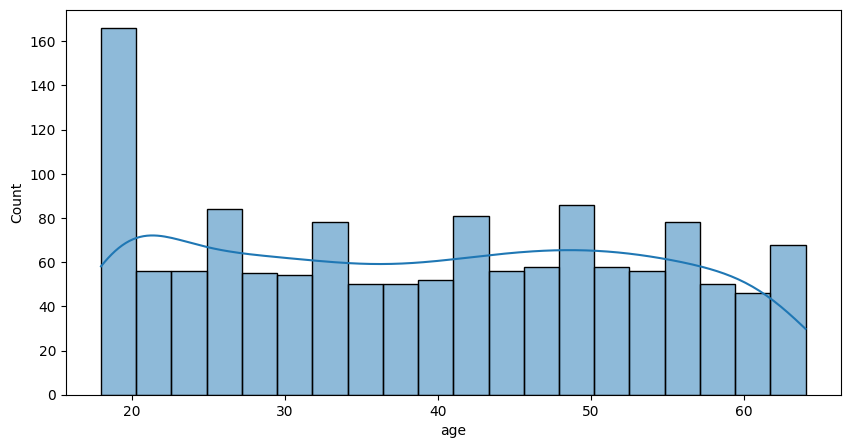

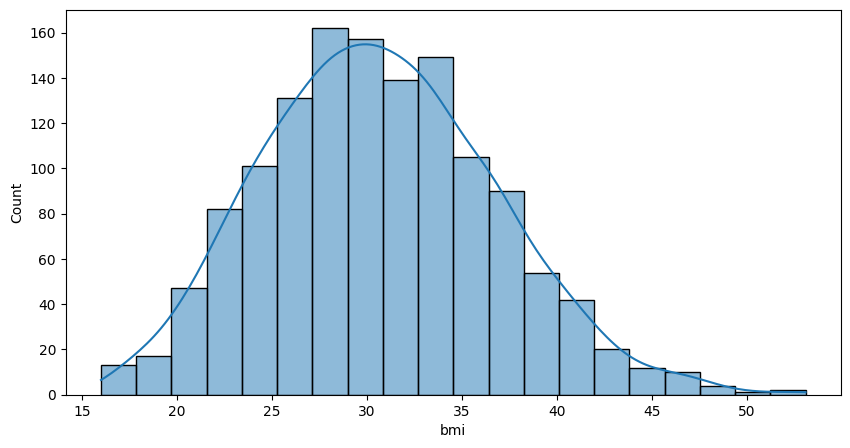

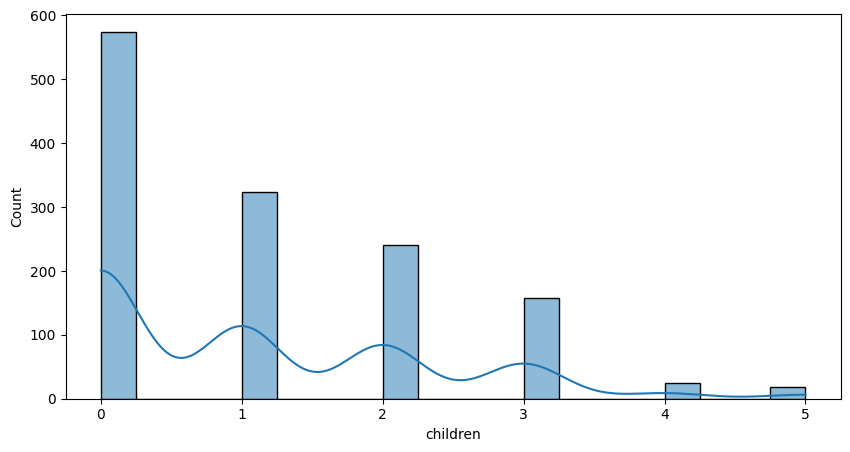

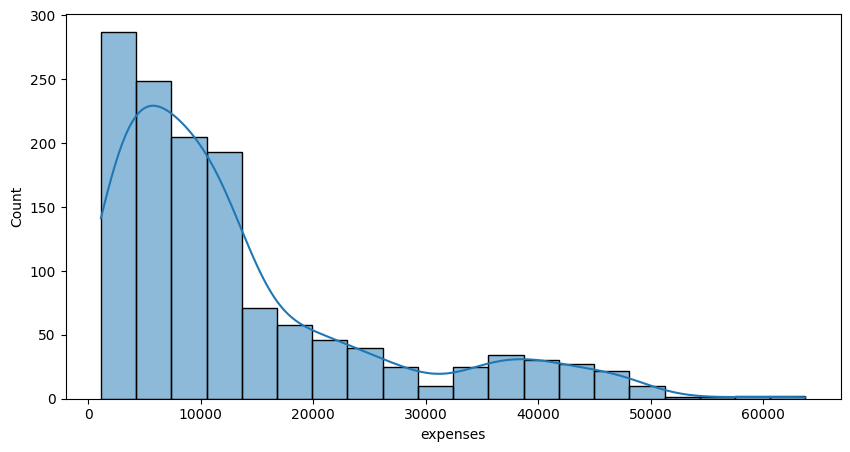

In [ ]:
numeric_val=['age', 'bmi', 'children', 'expenses']
for i in numeric_val:
    plt.figure(figsize=(10,5))
    sns.histplot(df[i], kde=True,bins=20)
   

<Axes: xlabel='sex', ylabel='count'>

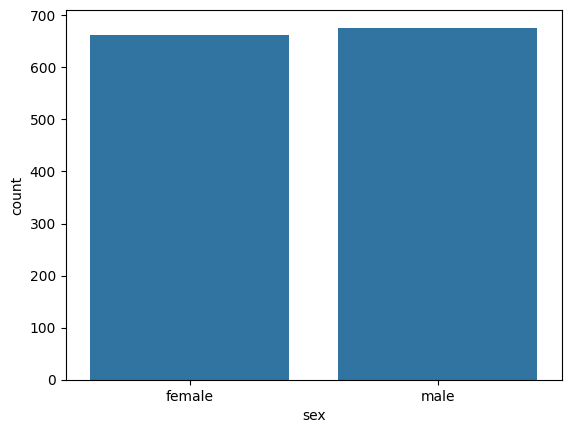

In [ ]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

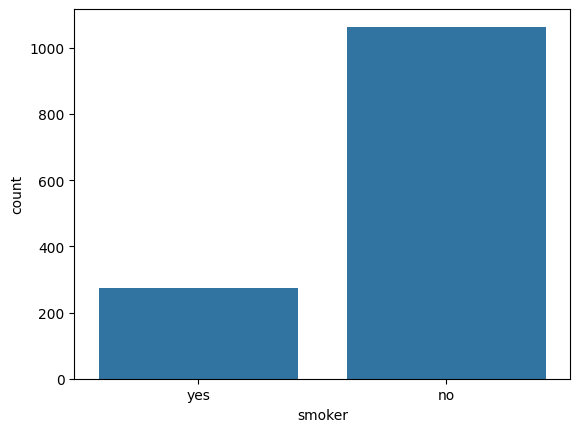

In [ ]:
sns.countplot(x=df['smoker'])

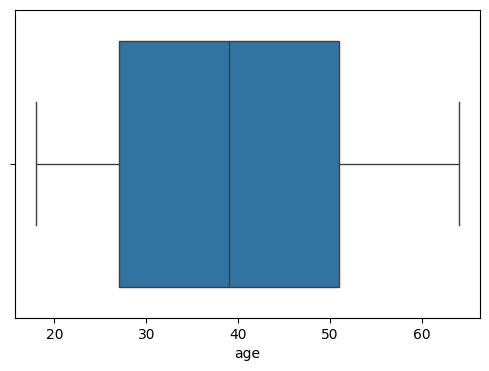

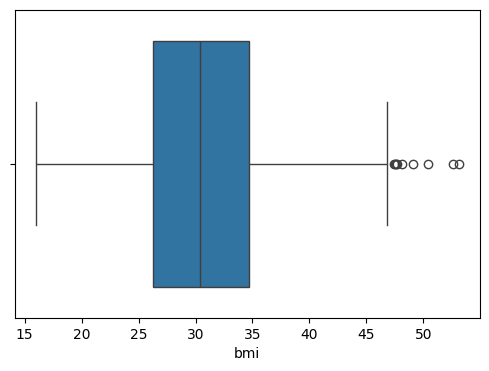

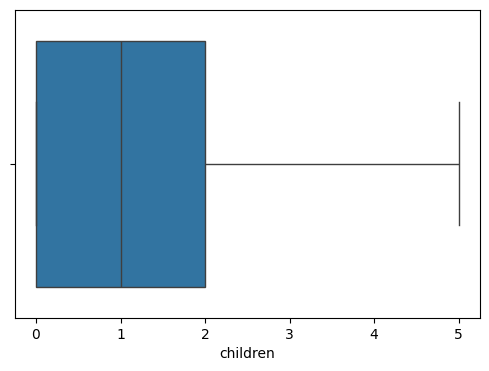

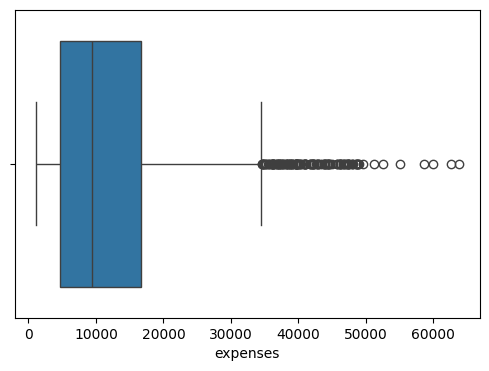

In [ ]:
for col in numeric_val:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

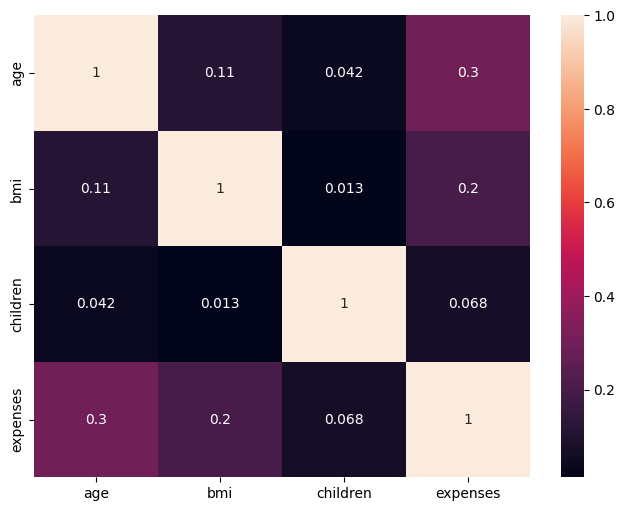

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
#Data Cleaning and pre processing

In [ ]:
df_cleaneed = df.copy()


In [ ]:
df.shape

(1338, 7)

In [ ]:
df_cleaneed.drop_duplicates(inplace=True)

In [ ]:
df_cleaneed.shape

(1337, 7)

In [ ]:
df_cleaneed['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [ ]:
df_cleaneed['sex']=df_cleaneed['sex'].map({'male':0,'female':1})

In [ ]:
df_cleaneed.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,yes,southwest,16884.92
1,18,0,33.8,1,no,southeast,1725.55
2,28,0,33.0,3,no,southeast,4449.46
3,33,0,22.7,0,no,northwest,21984.47
4,32,0,28.9,0,no,northwest,3866.86


In [ ]:
df_cleaneed['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [ ]:
df_cleaneed['smoker']=df_cleaneed['smoker'].map({'yes':1,'no':0})

In [ ]:
df_cleaneed.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [ ]:
df_cleaneed.rename(columns={
    'isFemale':'is_Female',
    'isSmoker':'is_Smoker'}, inplace=True)

In [ ]:
df_cleaneed.head()

,age,is_Female,bmi,children,is_Smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [ ]:
df_cleaneed=pd.get_dummies(df_cleaneed, columns=['region'], drop_first=True)

In [ ]:
df_cleaneed.head()

,age,is_Female,bmi,children,is_Smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27.9,0,1,16884.92,False,False,True
1,18,0,33.8,1,0,1725.55,False,True,False
2,28,0,33.0,3,0,4449.46,False,True,False
3,33,0,22.7,0,0,21984.47,True,False,False
4,32,0,28.9,0,0,3866.86,True,False,False


In [ ]:
df_cleaneed.astype(int).head()

,age,is_Female,bmi,children,is_Smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [ ]:
#Feature Engeneering and Extracting important features

In [ ]:
df_cleaneed['bmi_category'] = pd.cut(df_cleaneed['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [ ]:
df_cleaneed.head()

,age,is_Female,bmi,children,is_Smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.9,0,1,16884.92,False,False,True,Overweight
1,18,0,33.8,1,0,1725.55,False,True,False,Obese
2,28,0,33.0,3,0,4449.46,False,True,False,Obese
3,33,0,22.7,0,0,21984.47,True,False,False,Normal
4,32,0,28.9,0,0,3866.86,True,False,False,Overweight


In [ ]:
df_cleaneed = pd.get_dummies(df_cleaneed, columns=['bmi_category'], drop_first=True)

In [ ]:
df_cleaneed.head()

,age,is_Female,bmi,children,is_Smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.9,0,1,16884.92,False,False,True,False,True,False
1,18,0,33.8,1,0,1725.55,False,True,False,False,False,True
2,28,0,33.0,3,0,4449.46,False,True,False,False,False,True
3,33,0,22.7,0,0,21984.47,True,False,False,True,False,False
4,32,0,28.9,0,0,3866.86,True,False,False,False,True,False


In [ ]:
df_cleaneed.astype(int).head()

,age,is_Female,bmi,children,is_Smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [ ]:
df_cleaneed.columns

Index(['age', 'is_Female', 'bmi', 'children', 'is_Smoker', 'expenses',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [57]:
from sklearn.preprocessing import StandardScaler
cols=['age', 'bmi', 'children']
scaler=StandardScaler()
df_cleaneed[cols]=scaler.fit_transform(df_cleaneed[cols])


In [58]:
df_cleaneed.head()

,age,is_Female,bmi,children,is_Smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.453484,-0.909234,1,16884.92,False,False,True,False,True,False
1,-1.511647,0,0.513986,-0.079442,0,1725.55,False,True,False,False,False,True
2,-0.799350,0,0.382803,1.580143,0,4449.46,False,True,False,False,False,True
3,-0.443201,0,-1.306169,-0.909234,0,21984.47,True,False,False,True,False,False
4,-0.514431,0,-0.289506,-0.909234,0,3866.86,True,False,False,False,True,False


In [62]:
from scipy.stats import pearsonr

selected_features= [
    'age',
    'is_Female',
    'bmi',
    'children',
    'is_Smoker',
    'expenses',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]
correlations = {
    feature: pearsonr(df_cleaneed[feature], df_cleaneed['expenses'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson_Correlation'])
correlation_df.sort_values(by='Pearson_Correlation', ascending=False)

,Feature,Pearson_Correlation
5,expenses,1.000000
4,is_Smoker,0.787234
0,age,0.298308
11,bmi_category_Obese,0.200347
2,bmi,0.198637
7,region_southeast,0.073578
3,children,0.067389
6,region_northwest,-0.038695
8,region_southwest,-0.043637
1,is_Female,-0.058045


In [63]:
cat_features= [
    'is_Female',
    'is_Smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]

In [65]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaneed['expenses_bin'] = pd.qcut(df_cleaneed['expenses'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency_table = pd.crosstab(df_cleaneed[col], df_cleaneed['expenses_bin'])
    chi2_stat, p, dof, expected = chi2_contingency(contingency_table)
    decision = 'Reject Null Hypothesis' if p < alpha else 'Accept all Null (Drop the feature)'
    chi2_results[col] = {'chi2_statistic': chi2_stat, 'p_value': p, 'Decision':decision}
chi2_df=pd.DataFrame(chi2_results).T
chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_Female,10.258784,0.01649,Reject Null Hypothesis
is_Smoker,848.219178,0.0,Reject Null Hypothesis
region_northwest,1.13424,0.768815,Accept all Null (Drop the feature)
region_southeast,15.998167,0.001135,Reject Null Hypothesis
region_southwest,5.091893,0.165191,Accept all Null (Drop the feature)
bmi_category_Normal,4.263673,0.234364,Accept all Null (Drop the feature)
bmi_category_Overweight,4.873307,0.181313,Accept all Null (Drop the feature)
bmi_category_Obese,8.515711,0.036473,Reject Null Hypothesis


In [70]:
final_df= df_cleaneed[['age', 'bmi', 'children', 'is_Smoker', 'expenses', 'is_Female', 'region_southeast', 'bmi_category_Obese']]

In [71]:
final_df[
    ['bmi_category_Obese', 'is_Female', 'is_Smoker', 'region_southeast']
] = final_df[
    ['bmi_category_Obese', 'is_Female', 'is_Smoker', 'region_southeast']
].astype(int)

In [72]:
final_df.head()

,age,bmi,children,is_Smoker,expenses,is_Female,region_southeast,bmi_category_Obese
0,-1.440418,-0.453484,-0.909234,1,16884.92,1,0,0
1,-1.511647,0.513986,-0.079442,0,1725.55,0,1,1
2,-0.799350,0.382803,1.580143,0,4449.46,0,1,1
3,-0.443201,-1.306169,-0.909234,0,21984.47,0,0,0
4,-0.514431,-0.289506,-0.909234,0,3866.86,0,0,0
